## Fórmula

O KNN utiliza uma função de distância (geralmente a distância Euclidiana) para medir o quão parecido um ponto é do outro.   
Quanto menor a distância, mais próximos os pontos estão.    
A predição é feita considerando os k vizinhos mais próximos.    

## Características

É um algoritmo não paramétrico, ou seja, não assume nenhuma forma específica para a distribuição dos dados.

- Baseia-se em distâncias, portanto todas as variáveis devem estar na mesma escala (normalização é recomendada).    
- O custo computacional da predição pode ser alto em bases grandes, pois o algoritmo compara o ponto a ser previsto com todos os pontos de treino.  
- A escolha de k influencia fortemente o resultado:     
    k pequeno → modelo mais sensível a ruído     
    k grande → modelo mais estável, porém pode perder detalhes   
- Funciona tanto para classificação quanto regressão.   

## Hiperparâmetro

n_neighbors

Representa quantos vizinhos serão considerados para fazer a predição.

- Ex.: n_neighbors = 5 → usa os 5 pontos mais próximos para votar (classificação) ou fazer média (regressão).

## Funcionamento

•	KNN usa distância para classificar novos dados.     
•	Não cria modelo matemático, apenas compara com os vizinhos.     
•	Processo: criar → treinar → prever      

## Código

c:\Users\disrct\AppData\Local\Programs\Python\Python312\Lib\site-packages\yellowbrick\classifier\base.py:232: YellowbrickWarning: could not determine class_counts_ from previously fitted classifier
  warnings.warn(


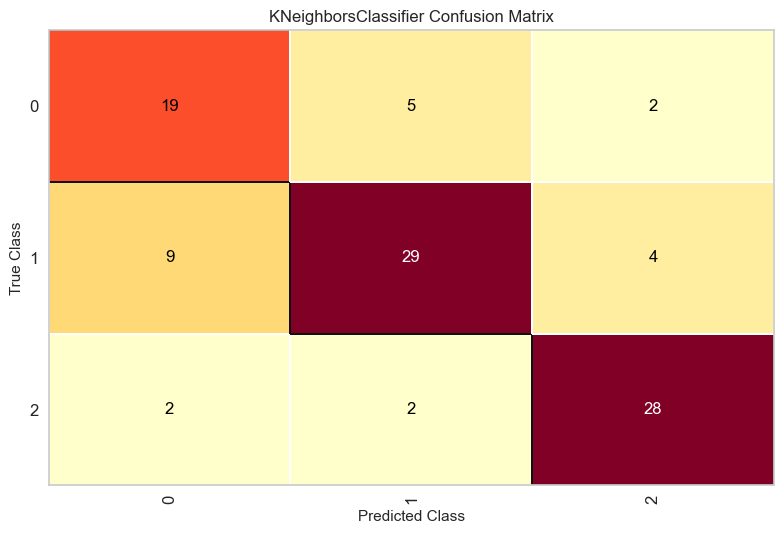

Accuracy: 0.76


In [4]:
# ===============================
# 1. Criar base de dados sintética
# ===============================
from sklearn.datasets import make_classification  # import acima do uso

X, y = make_classification(
    n_samples=500,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_classes=3,
    random_state=42
)


# ===============================
# 2. Separar treino e teste
# ===============================
from sklearn.model_selection import train_test_split  # import acima do uso

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# ===============================
# 3. Padronizar os dados
# ===============================
from sklearn.preprocessing import StandardScaler  # import acima do uso

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


# ===============================
# 4. Criar e treinar o modelo KNN
# ===============================
from sklearn.neighbors import KNeighborsClassifier  # import acima do uso

modelo = KNeighborsClassifier(n_neighbors=5)
modelo.fit(X_train, y_train)


# ===============================
# 5. Fazer previsões
# ===============================
y_pred = modelo.predict(X_test)


# ===============================
# 6. Accuracy Score
# ===============================
from sklearn.metrics import accuracy_score  # import acima do uso

accuracy = accuracy_score(y_test, y_pred)


# ===============================
# 7. Matriz de Confusão (Yellowbrick)
# ===============================
from yellowbrick.classifier import ConfusionMatrix  # import acima do uso

viz = ConfusionMatrix(modelo)
viz.score(X_test, y_test)  # gera as previsões internamente
viz.show()                 # exibe o gráfico


# ===============================
# 8. Exibir resultados numéricos
# ===============================
print("Accuracy:", accuracy)
